### Pengembangan Intelligent Cryptocurrency Market Intelligence System Berbasis Data Pipeline dan Machine Learning

Nama Anggota Kelompok:
1. Gaitsa Nazwa Kansa (24083010014)
2. Auliya Khotimatuz Zahroh (24083010061)
3. Carissa Naura Rajwa (24083010063)

# Konsep Project
Perkembangan pasar cryptocurrency dalam beberapa tahun terakhir menunjukkan dinamika harga yang sangat fluktuatif. Perubahan harga yang cepat sering kali menyulitkan investor dalam menentukan keputusan investasi yang tepat. Oleh karena itu, diperlukan suatu sistem yang mampu mengolah data pasar cryptocurrency secara otomatis serta menyajikan informasi yang informatif dan mudah dipahami.


Dalam proyek ini akan dikembangkan sebuah sistem analisis pasar cryptocurrency berbasis data pipeline, machine learning, dan dashboard interaktif. Sistem ini bertujuan untuk mengolah data pasar cryptocurrency secara otomatis mulai dari proses pengambilan data hingga menghasilkan informasi analitis yang dapat membantu pengguna dalam memahami kondisi pasar.

# Sumber Data
Data yang digunakan dalam penelitian ini diperoleh dari API publik milik CoinGecko. API ini menyediakan berbagai informasi terkait pasar cryptocurrency seperti harga aset, kapitalisasi pasar, serta volume transaksi.

Pada tahap awal proyek, data yang diambil meliputi beberapa cryptocurrency utama yang memiliki kapitalisasi pasar besar, yaitu:

- Bitcoin (BTC)
- Ethereum (ETH)
- Solana (SOL)

Data yang dikumpulkan berupa data historis selama kurang lebih satu tahun terakhir dengan interval harian. Variabel utama yang digunakan dalam dataset meliputi:
- tanggal (date)
- harga aset (price)
- kapitalisasi pasar (market_cap)
- volume perdagangan (volume)

Dataset yang dihasilkan kemudian disimpan dalam format CSV untuk memudahkan proses analisis selanjutnya.

#Sistem yang Dibangun
Proyek ini mengembangkan sebuah sistem analisis cryptocurrency yang terdiri dari beberapa komponen utama, yaitu data pipeline, analisis data eksploratif, model machine learning, serta dashboard visualisasi.

Secara umum alur sistem yang dibangun adalah sebagai berikut:
1. Data Collection
Data cryptocurrency diambil secara otomatis dari API CoinGecko menggunakan bahasa pemrograman Python.
2. Data Pipeline
Data yang diperoleh kemudian diproses melalui tahapan pembersihan data (data cleaning) dan transformasi data untuk menghasilkan dataset yang siap digunakan dalam analisis dan pemodelan.
3. Feature Engineering
Pada tahap ini akan dibuat beberapa variabel tambahan seperti:
- return harian
- volatilitas harga
- moving average
Variabel-variabel tersebut digunakan untuk memahami dinamika pergerakan harga cryptocurrency.
4. Machine Learning
Dataset yang telah diproses akan digunakan untuk membangun model machine learning dengan dua tujuan utama, yaitu:
- prediksi harga cryptocurrency untuk beberapa hari ke depan
- klasifikasi fase pasar (bullish, bearish, atau sideways)
Dashboard Visualisasi
Hasil analisis dan prediksi kemudian akan ditampilkan dalam sebuah dashboard interaktif menggunakan Streamlit sehingga pengguna dapat dengan mudah memantau kondisi pasar cryptocurrency secara visual.

# Tujuan Pengembangan Sistem

Tujuan utama dari proyek ini yaitu untuk :
1. membangun pipeline pengolahan data cryptocurrency berbasis API
2. melakukan eksplorasi pola pergerakan harga cryptocurrency
3. membangun model machine learning untuk prediksi harga dan klasifikasi fase pasar
4. menyajikan hasil analisis dalam bentuk dashboard interaktif

Dengan adanya sistem ini diharapkan pengguna dapat memperoleh informasi yang lebih komprehensif mengenai kondisi pasar cryptocurrency sehingga dapat membantu dalam proses pengambilan keputusan investasi.

In [ ]:
pip install requests pandas matplotlib scikit-learn

`pip install requests pandas matplotlib scikit-learn` digunakan untuk menginstall library yang dibutuhkan yaitu `pandas`, `matplotlib`, dan `scikit-learn`. Selain itu, pada bagian `requests` digunakan untuk mengambil dan meminta dari server CoinGecko.


In [ ]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": "365"
}

response = requests.get(url, params=params)
data = response.json()

# Ambil harga, market cap, volume
prices = data["prices"]
market_caps = data["market_caps"]
volumes = data["total_volumes"]

# Buat dataframe
df_price = pd.DataFrame(prices, columns=["timestamp", "price"])
df_market = pd.DataFrame(market_caps, columns=["timestamp", "market_cap"])
df_volume = pd.DataFrame(volumes, columns=["timestamp", "volume"])

df = df_price.merge(df_market, on="timestamp")
df = df.merge(df_volume, on="timestamp")

df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df[["date", "price", "market_cap", "volume"]]

df.head()

,date,price,market_cap,volume
0,2025-03-04,86124.714187,1.708199e+12,6.871536e+10
1,2025-03-05,87310.805311,1.731442e+12,6.586336e+10
2,2025-03-06,90604.080985,1.797707e+12,5.160664e+10
3,2025-03-07,90001.400876,1.782786e+12,4.755576e+10
4,2025-03-08,86773.335976,1.720437e+12,6.321644e+10


`url = ....` digunakan untuk menentukan alamat API tempat data Bitcoin disimpan.


`params = ...` digunakan untuk memfilter data, dengan ketentuan hanya mengambil data dalam mata uang USD dan rentang waktu 365 hari ke belakang.

`response = requests.get(url, params=params)
data = response.json()` digunakan untuk mengirim permintaan ke url yang telah ditenteukan, lalu mengubah jawaban dari server menjadi format yang bisa dibaca Python (*dictionary*).

`prices = data["prices"]
market_caps = data["market_caps"]
volumes = data["total_volumes"]` digunakan untuk mengambil tiga kategori data spesifik dari hasil API, yaitu harga, nilai pasar, dan volume transaksi.

`df_price = ...`
`df_market = ...`
`df_volume = ...` digunakan untuk mengubah daftar angka menjadi tabel *DataFrame* dan memberi nama kolomnya.

`df = df_price.merge(df_market, on="timestamp")`
`df = df.merge(df_volume, on="timestamp")` digunakan untuk menggabungkan ketiga tabel menjadi satu tabel besar berdasarkan kolom `timestamp`.

`df["date"] = pd.to_datetime(df["timestamp"], unit="ms")` mengubah format tanggal menjadi format tanggal dari python agar dapat diproses.

`df = df[["date", "price", "market_cap", "volume"]]` digunakan utnuk menyusun ulang urutan kolom dan membuang kolom `trimestamp` lama karena sudah ada kolom `date` yang lebih rapi.


In [ ]:
df.to_csv("bitcoin_data.csv", index=False)

from google.colab import files
files.download("bitcoin_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

`df.to_csv("bitcoin_data.csv", index=False)` digunakan untuk menyimpan tabel dataset ke dalam file Excel dalam format CSV.

`from google.colab import files
files.download("bitcoin_data.csv")` digunakan untuk mendownload file CSV.

In [ ]:
df["return"] = df["price"].pct_change()
df["volatility_7d"] = df["return"].rolling(7).std()

df.tail()

,date,price,market_cap,volume,return,volatility_7d
361,2026-02-23 00:00:00,67585.117189,1.350654e+12,2.035477e+10,-0.005778,0.012632
362,2026-02-24 00:00:00,64577.553201,1.291179e+12,5.672440e+10,-0.044500,0.019971
363,2026-02-25 00:00:00,64074.110985,1.281148e+12,4.486448e+10,-0.007796,0.019315
364,2026-02-26 00:00:00,67947.391856,1.358175e+12,5.474762e+10,0.060450,0.031447
365,2026-02-26 15:11:21,67432.439176,1.350526e+12,5.682959e+10,-0.007579,0.031667


`df["return"] = df["price"].pct_change()` digunakan untuk membuat kolom baru untuk melihat keuntungan harian dalam bentuk persen.

`df["volatility_7d"] = df["return"].rolling(7).std()` digunakan untuk menghitung seperapa fluktuatif harga Bitcoin dalam seminggu terakhir menggunakan rumus standar devias.

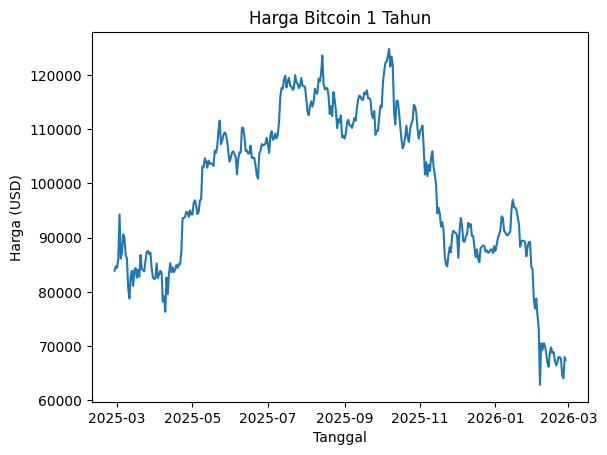

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["date"], df["price"])
plt.title("Harga Bitcoin 1 Tahun")
plt.xlabel("Tanggal")
plt.ylabel("Harga (USD)")
plt.show()

Dapat dilihat bahwa dari bulan Maret 2025 hingga Juli 2025, harga Bitcoin menunjukkan tren kenaikan yang cukup stabil, bergerak dari kisaran 80.000 USD menuju 100.000 USD.

Memasuki bulan Oktober 2025, grafik menunjukkan titik puncak dimana harga menembus angka diatas 120.000 USD. Pada bulan ini merupakan eprforma tertinggi Bitcoin dalam periode satu tahun.

Setelah mencapai puncaknya, terlihat adanya fase konsolidasi diantara bulan November 2025 hingga Januari 2026, di mana harga tertahan di harga 90.000 USD.

Lalu terjadi penurunan yang sangat drastis pada bulan Februari 2026. Harga anjlok secara signifikan hingga menyentuh level terendahnya di sekitar 65.000 USD hanya dalam waktu dua bulan.

Pada akhir periode, yaitu Maret 2025, harga tampak sednag berusaha mencari landasan stabil setelah turun cukup drastik, dengan berada di harga 68.000 USD.


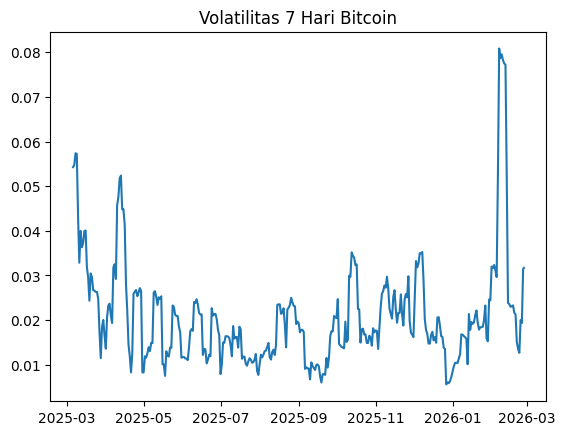

In [ ]:
plt.figure()
plt.plot(df["date"], df["volatility_7d"])
plt.title("Volatilitas 7 Hari Bitcoin")
plt.show()

Dapat dilihat bahwa pada Februari 2026, grafik mencapai titik tertingginya (di atas 0.08). Ini menunjukkan bahwa penurunan harga tajam terjadi dengan sangat cepat dan agresif, memicu kepanikan atau gejolak pasar yang luar biasa.

Jika dibandingkan, setiap kali ada penurunan atau kenaikan harga yang sangat curam di grafik harga, grafik volatilitas akan ikut melonjak. Contohnya pada Maret 2025 dan Februari 2026.

Dapat dilihat bahwa di pertengahan tahun, volatilitas cenderung rendah dan stabil (di bawah 0.02). Ini menandakan bahwa meskipun harga Bitcoin sedang tinggi di periode tersebut, pergerakannya jauh lebih tenang dan tidak banyak kejutan drastis.

Secara keseluruhan, grafik ini menunjukkan bahwa investasi Bitcoin di awal 2026 memiliki risiko yang jauh lebih tinggi dibandingkan pertengahan 2025 karena fluktuasi harga yang sangat ekstrem.


In [ ]:
from sklearn.cluster import KMeans

X = cluster_df[["return", "volatility_7d"]]

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(X)

cluster_df.head()

/tmp/ipython-input-863/3197847695.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df["cluster"] = kmeans.fit_predict(X)


,date,price,market_cap,volume,return,volatility_7d,cluster
7,2025-03-06,90604.080985,1.797707e+12,5.160664e+10,0.037719,0.054259,0
8,2025-03-07,90001.400876,1.782786e+12,4.755576e+10,-0.006652,0.054740,1
9,2025-03-08,86773.335976,1.720437e+12,6.321644e+10,-0.035867,0.057381,1
10,2025-03-09,86142.983359,1.708606e+12,1.880936e+10,-0.007264,0.057219,1
11,2025-03-10,80751.138933,1.602074e+12,3.201341e+10,-0.062592,0.043339,1


`X = cluster_df[["return", "volatility_7d"]]` digunakan untuk menentukan variabel untuk *clustering*.

`kmeans = KMeans(n_clusters=2, random_state=42)` digunakan untuk membagi data sesuai dengan *cluster* yang telah ditentukan sebelumnya.

`cluster_df["cluster"] = kmeans.fit_predict(X)` digunakan untuk memberikan label ke dalam setiap bari data


